<a href="https://colab.research.google.com/github/mecalme/Miniprojeto_MarioEnriqueMedina_Analise_de_Dados_T6/blob/main/Mini_Projeto_Avaliativo_M%C3%B3dulo_1_Semana_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

         RELATÓRIO COMPARATIVO DE TRATAMENTO DE DADOS (ETL)
Métrica / Indicador          | ANTES            | DEPOIS          
--------------------------------------------------------------------
Total de Linhas              | 830.000          | 733.447         
Total de Colunas             | 14               | 10              
Linhas Duplicadas            | 96.553           | 0               
Valores Nulos Totais         | 3.320.000        | 428636          
Inconsistências (#N/D)       | 3.650            | 0               
Tipo da Coluna DATA          | object           | datetime64[ns]  

 Arquivo exportado: /content/drive/MyDrive/Colab Notebooks/Analise de Dados /Varejocsv_tratado.csv

--- ESTATÍSTICAS DESCRITIVAS: FILHOS DO CLIENTE (CL_FHL) ---
count    733447.000000
mean          1.146049
std           1.416917
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max           4.000000
Name: CL_FHL, dtype: float64
Moda: 0

Gerando painel grá

/tmp/ipykernel_3528/2690489583.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_counts, x="Total", y="Categoria", ax=axs[0, 1], palette="Blues_r")
/tmp/ipykernel_3528/2690489583.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="CL_FHL", ax=axs[1, 0], palette="Greens_d")
/tmp/ipykernel_3528/2690489583.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=compras_genero, x="Gênero", y="Compras_Unicas", ax=axs[1, 1], palette="Set2")


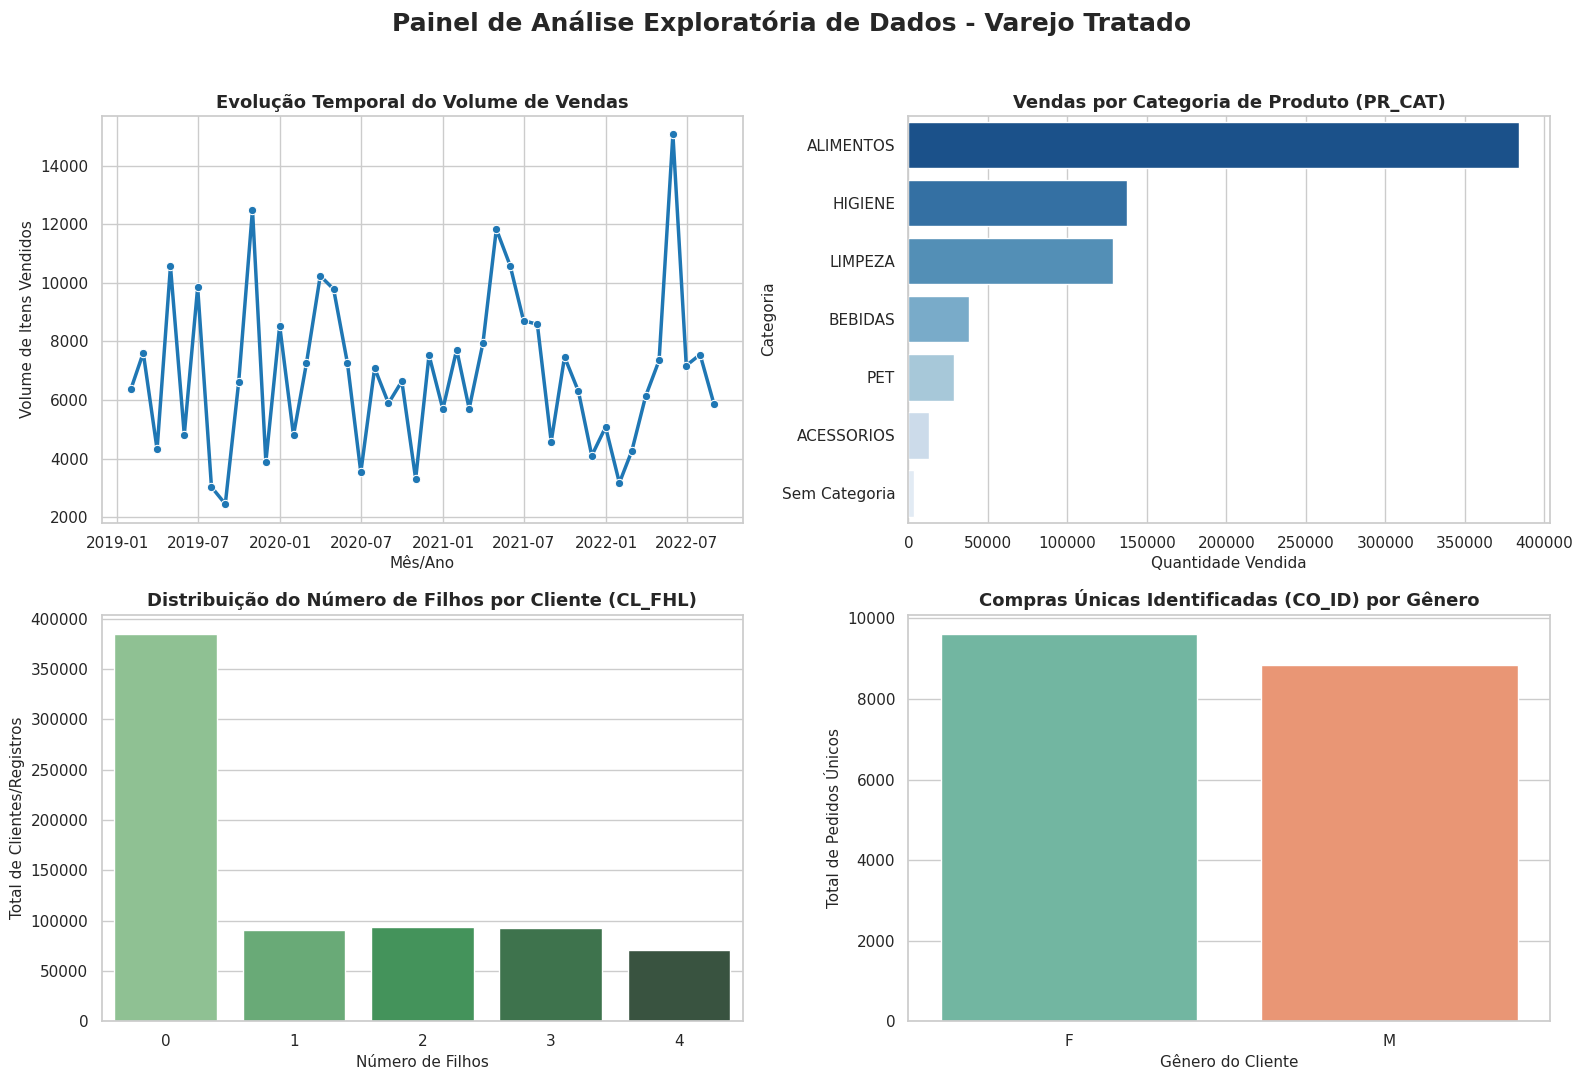

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração global do tema visual do Seaborn
sns.set_theme(style="whitegrid", palette="muted")

# 1. Caminhos dos arquivos no Google Drive
caminho_entrada = "/content/drive/MyDrive/Colab Notebooks/Analise de Dados /Base Varejo.csv"
caminho_saida = "/content/drive/MyDrive/Colab Notebooks/Analise de Dados /Varejocsv_tratado.csv"

# 2. Leitura da base original
df_raw = pd.read_csv(caminho_entrada, sep=";", encoding="utf-8")

# --- COLETA DE MÉTRICAS (ANTES) ---
linhas_antes = len(df_raw)
colunas_antes = df_raw.shape[1]
duplicadas_antes = df_raw.duplicated().sum()
nulos_totais_antes = df_raw.isnull().sum().sum()
nd_cat_antes = (df_raw["PR_CAT"] == "#N/D").sum() if "PR_CAT" in df_raw.columns else 0
dtype_data_antes = df_raw["DATA"].dtype

# 3. TRATAMENTO E LIMPEZA
df = df_raw.copy()

# A. Remoção de colunas excedentes 'Unnamed'
col_unnamed = [col for col in df.columns if "Unnamed" in col]
df.drop(columns=col_unnamed, inplace=True)

# B. Remoção de duplicatas
df.drop_duplicates(inplace=True)

# C. Tratamento de inconsistências #N/D e preenchimento
df["PR_CAT"] = df["PR_CAT"].replace("#N/D", "Sem Categoria").fillna("Sem Categoria")
df["PR_NOME"] = df["PR_NOME"].replace("#N/D", "Sem Nome").fillna("Sem Nome")

# D. Conversão de tipo de dado (DATA para datetime)
df["DATA"] = pd.to_datetime(df["DATA"], errors="coerce")

# --- COLETA DE MÉTRICAS (DEPOIS) ---
linhas_depois = len(df)
colunas_depois = df.shape[1]
duplicadas_depois = df.duplicated().sum()
nulos_totais_depois = df.isnull().sum().sum()
nd_cat_depois = (df["PR_CAT"] == "#N/D").sum()
dtype_data_depois = df["DATA"].dtype

# 4. IMPRESSÃO DO RELATÓRIO COMPARATIVO NO TERMINAL
print("=" * 68)
print("         RELATÓRIO COMPARATIVO DE TRATAMENTO DE DADOS (ETL)")
print("=" * 68)
print(f"{'Métrica / Indicador':<28} | {'ANTES':<16} | {'DEPOIS':<16}")
print("-" * 68)
print(f"{'Total de Linhas':<28} | {linhas_antes:<16,} | {linhas_depois:<16,}".replace(",", "."))
print(f"{'Total de Colunas':<28} | {colunas_antes:<16} | {colunas_depois:<16}")
print(f"{'Linhas Duplicadas':<28} | {duplicadas_antes:<16,} | {duplicadas_depois:<16}".replace(",", "."))
print(f"{'Valores Nulos Totais':<28} | {nulos_totais_antes:<16,} | {nulos_totais_depois:<16}".replace(",", "."))
print(f"{'Inconsistências (#N/D)':<28} | {nd_cat_antes:<16,} | {nd_cat_depois:<16}".replace(",", "."))
print(f"{'Tipo da Coluna DATA':<28} | {str(dtype_data_antes):<16} | {str(dtype_data_depois):<16}")
print("=" * 68)

# 5. Salvamento do arquivo tratado no Drive
df.to_csv(caminho_saida, sep=";", index=False, encoding="utf-8")
print(f"\n Arquivo exportado: {caminho_saida}")

# 6. ESTATÍSTICAS DESCRITIVAS
print("\n--- ESTATÍSTICAS DESCRITIVAS: FILHOS DO CLIENTE (CL_FHL) ---")
stats = df["CL_FHL"].describe(percentiles=[0.25, 0.5, 0.75])
moda = df["CL_FHL"].mode()[0]
print(stats)
print(f"Moda: {moda}")

# 7. VISUALIZAÇÕES DE DADOS COM SEABORN (2x2 SUBPLOTS)
print("\nGerando painel gráfico com Seaborn...")
fig, axs = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Painel de Análise Exploratória de Dados - Varejo Tratado", fontsize=18, fontweight="bold", y=0.98)

# A. Gráfico de Linha: Evolução Mensal do Volume de Itens
vendas_mensais = df.resample("ME", on="DATA")["CO_ID"].count().reset_index()
sns.lineplot(data=vendas_mensais, x="DATA", y="CO_ID", ax=axs[0, 0], marker="o", color="#1f77b4", linewidth=2.5)
axs[0, 0].set_title("Evolução Temporal do Volume de Vendas", fontsize=13, fontweight="bold")
axs[0, 0].set_xlabel("Mês/Ano", fontsize=11)
axs[0, 0].set_ylabel("Volume de Itens Vendidos", fontsize=11)

# B. Gráfico de Barras: Volume por Categoria de Produto
cat_counts = df["PR_CAT"].value_counts().reset_index()
cat_counts.columns = ["Categoria", "Total"]
sns.barplot(data=cat_counts, x="Total", y="Categoria", ax=axs[0, 1], palette="Blues_r")
axs[0, 1].set_title("Vendas por Categoria de Produto (PR_CAT)", fontsize=13, fontweight="bold")
axs[0, 1].set_xlabel("Quantidade Vendida", fontsize=11)
axs[0, 1].set_ylabel("Categoria", fontsize=11)

# C. Gráfico de Contagem (Countplot): Distribuição do Número de Filhos
sns.countplot(data=df, x="CL_FHL", ax=axs[1, 0], palette="Greens_d")
axs[1, 0].set_title("Distribuição do Número de Filhos por Cliente (CL_FHL)", fontsize=13, fontweight="bold")
axs[1, 0].set_xlabel("Número de Filhos", fontsize=11)
axs[1, 0].set_ylabel("Total de Clientes/Registros", fontsize=11)

# D. Gráfico de Barras: Compras Únicas por Gênero
compras_genero = df.groupby("CL_GENERO")["CO_ID"].nunique().reset_index()
compras_genero.columns = ["Gênero", "Compras_Unicas"]
sns.barplot(data=compras_genero, x="Gênero", y="Compras_Unicas", ax=axs[1, 1], palette="Set2")
axs[1, 1].set_title("Compras Únicas Identificadas (CO_ID) por Gênero", fontsize=13, fontweight="bold")
axs[1, 1].set_xlabel("Gênero do Cliente", fontsize=11)
axs[1, 1].set_ylabel("Total de Pedidos Únicos", fontsize=11)

# Ajuste de espaçamento e salvamento do painel visual
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("/content/drive/MyDrive/Colab Notebooks/Analise de Dados /painel_visualizacao_varejo.png", dpi=300, bbox_inches="tight")
plt.show()